# Benchmarks analysis notebook

This notebook is used to analyze the ablation of supervised learning for ts-tcc encoder

## Define base configs

In [1]:
import pandas as pd
metric_used = 'accuracy'
apply_correction_factor = True


def extract_metric_target(df):
    metric_map = {
        "har": "accuracy",
        "hapt": "accuracy"
    }
    return df["pipeline/task"].map(metric_map)


def extract_metric(df):
    metric_results = []
    metric_map = {
        "har": "metric/classification/accuracy",
        "hapt": "metric/classification/accuracy",
    }

    for _, row in df.iterrows():
        metric_column = metric_map[row["pipeline/task"]]
        metric_value = row[metric_column]
        metric_results.append(metric_value)

    return metric_results

In [2]:
import sys
from pathlib import Path

# Use the current working directory instead of __file__
sys.path.append(str(Path.cwd().parent))

# use utils from previous folder
from utils import (
    calculate_variant_wilcoxon,
    create_precedence_graph,
    prepare_experiment_df,
    plot_comparison_bar
)

# disable warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Path to the experiment results (parsed) summarized_executions_fixed
filename = 'saved_metrics_paper_daghar_supervised_3runs_perlr_samples_down_seed_resnetse5_12345'
summarized_executions_path = Path(f"{filename}.csv")

# summarized_executions_path = Path("summarized_executions_fixed.csv")

# Location to save figures and tables
figures_path = Path("results/figures/")
tables_path = Path("results/tables/")
figures_path.mkdir(parents=True, exist_ok=True)
tables_path.mkdir(parents=True, exist_ok=True)
print(f"Sucessfully created directories '{figures_path}' and '{tables_path}'")

Sucessfully created directories 'results/figures' and 'results/tables'


## Utility functions

First, we define some utility functions that will be used to parse the benchmarks results and to generate the plots.

In [4]:
def result_pairwise_wilcoxon(
    df, variants_variables, filters={}, show_stats=False,apply_bonferroni= False,
):
    df = prepare_experiment_df(
        df,
        **filters,
        verbose=True,
    )
    # display(df)
    if show_stats:
        print("Dataframe has", len(df.index), "rows")
        for col in df.columns:
            values = df[col].unique()
            print(f" - {col} ({len(values)})", values)

    return calculate_variant_wilcoxon(df, variants_variables, threshold=0.05,apply_bonferroni= apply_bonferroni)


def result_precedence_graph(
    df, variants_variables, filters={}, show_stdev=False,apply_bonferroni= False,show_df_tests=False
):
    w_df = result_pairwise_wilcoxon(df, variants_variables, filters,apply_bonferroni= apply_bonferroni,)
    if show_df_tests:
        print("Pairwise Wilcoxon test results:")
        display(w_df)
    return create_precedence_graph(w_df, show_stdev=show_stdev,apply_bonferroni= apply_bonferroni),w_df


def show_precedence_graph(
    df, variants_variables, filters, filename_suffix=None, show_stdev=False,apply_bonferroni= False,show_df_tests=False,filename=None
):

    dot,w_df = result_precedence_graph(
        df=df,
        variants_variables=variants_variables,
        filters=filters,
        show_stdev=show_stdev,
        apply_bonferroni=apply_bonferroni,
        show_df_tests=show_df_tests,
    )
    if filename is None:
        
        filename = "precedence_graph-" + "-".join(variants_variables)
    if filename_suffix:
        filename = filename + "-" + filename_suffix
    dot.render(
        filename=filename, directory=figures_path, format="png", cleanup=True
    )
    print(f"Precedence graph saved to '{figures_path / filename}.png'\n")
    display(dot)
    return dot,w_df


def summarize_backbone_performance(df):
    # Get all unique backbones (from both Variant 1 and Variant 2)
    all_backbones = set(df["Variant 1"]).union(set(df["Variant 2"]))
    
    # Initialize a dictionary to store stats for each backbone
    backbone_stats = {}
    
    for backbone in all_backbones:
        # Get all rows where the backbone appears (either in Variant 1 or Variant 2)
        mask = (df["Variant 1"] == backbone) | (df["Variant 2"] == backbone)
        relevant_rows = df[mask]
        
        # Extract means and stds where the backbone is involved
        means = []
        stds = []
        
        for _, row in relevant_rows.iterrows():
            if row["Variant 1"] == backbone:
                means.append(row["Variant 1 Mean"])
                stds.append(row["Variant 1 stdev"])
            else:
                means.append(row["Variant 2 Mean"])
                stds.append(row["Variant 2 stdev"])
        
        # Compute mean and std across all occurrences
        mean_performance = np.mean(means) if means else 0
        avg_std = np.mean(stds) if stds else 0
        
        backbone_stats[backbone] = {
            "Mean": mean_performance,
            "Std": avg_std,
            "Mean ± Std": f"{np.round(mean_performance*100, 1)}% ± {np.round(avg_std*100, 1)}%"
        }
    # --- Original logic for wins/losses ---
    sig_df = df[df["Significant"] == True].copy()
    
    # Determine winner and loser based on means
    sig_df["Winner"] = sig_df.apply(
        lambda row: row["Variant 1"] if row["Variant 1 Mean"] > row["Variant 2 Mean"] else row["Variant 2"], 
        axis=1
    )
    sig_df["Loser"] = sig_df.apply(
        lambda row: row["Variant 2"] if row["Variant 1 Mean"] > row["Variant 2 Mean"] else row["Variant 1"], 
        axis=1
    )
    
    # Count wins and losses
    win_counts = sig_df["Winner"].value_counts()
    loss_counts = sig_df["Loser"].value_counts()
    
    # Create summary DataFrame
    summary_df = pd.DataFrame.from_dict(backbone_stats, orient="index")
    summary_df.index.name = "Backbone"
    summary_df.reset_index(inplace=True)
    
    # Ensure all backbones are included (even if no wins/losses)
    summary_df["Wins"] = summary_df["Backbone"].map(win_counts).fillna(0).astype(int)
    summary_df["Losses"] = summary_df["Backbone"].map(loss_counts).fillna(0).astype(int)
    summary_df["Net Score"] = summary_df["Wins"] - summary_df["Losses"]
    
    # Sort by Net Score (descending)
    summary_df.sort_values(["Net Score", "Mean"], ascending=[False, False], inplace=True)
    
    return summary_df


In [5]:
def aggregate_backbone_performance(combined_df):
    """
    Processes a combined DataFrame of backbone results to produce:
    1. Technique-specific performance (mean ± std)
    2. Backbone totals across all techniques
    
    Args:
        combined_df: DataFrame containing results from multiple techniques
        
    Returns:
        tuple: (technique_summary_df, backbone_totals_df)
    """
    # --- Technique-Specific Summary ---
    technique_summary = combined_df.copy()
    
    # Convert to percentages if needed (assuming original means are 0-1)
    technique_summary["Mean"] = technique_summary["Mean"] * 100
    technique_summary["Std"] = technique_summary["Std"] * 100
    
    # Format performance string
    technique_summary["Performance"] = (
        technique_summary["Mean"].round(1).astype(str) + 
        "% ± " + 
        technique_summary["Std"].round(1).astype(str) + "%"
    )
    
    # Sort by Net Score then Mean
    technique_summary = technique_summary.sort_values(
        ["Net Score", "Mean"], 
        ascending=[False, False]
    )
    
    # --- Backbone Totals ---
    # Extract backbone name (before " + ")
    combined_df["Backbone Only"] = combined_df["Backbone"].str.split(" \+ ").str[0]
    
    # Group and aggregate
    backbone_totals = combined_df.groupby("Backbone Only").agg({
        "Wins": "sum",
        "Losses": "sum",
        "Net Score": "sum",
        "Mean": lambda x: np.mean(x) * 100,  # Convert to percentage
        "Std": lambda x: np.mean(x) * 100
    }).reset_index()
    
    # Format performance
    backbone_totals["Performance"] = (
        backbone_totals["Mean"].round(1).astype(str) + 
        "% ± " + 
        backbone_totals["Std"].round(1).astype(str) + "%"
    )
    
    # Clean up
    backbone_totals = backbone_totals.rename(columns={"Backbone Only": "Backbone"})
    backbone_totals = backbone_totals.sort_values(
        ["Net Score", "Mean"], 
        ascending=[False, False]
    )
    
    # Special handling for TS2Vec if present
    if "TS2Vec" in backbone_totals["Backbone"].values:
        backbone_totals["Backbone"] = backbone_totals["Backbone"].replace({
            "TS2Vec": "TS2Vec (Partial)"
        })
    
    # Select final columns
    backbone_totals = backbone_totals[["Backbone", "Performance", "Wins", "Losses", "Net Score"]]
    
    return technique_summary, backbone_totals

def generate_performance_tables(df_list, technique_names=None):
    """
    Complete workflow from individual technique DataFrames to final tables
    
    Args:
        df_list: List of DataFrames for each technique
        technique_names: Optional list of technique names
        
    Returns:
        tuple: (combined_df, technique_summary, backbone_totals)
    """
    # Add technique identifiers if provided
    if technique_names and len(technique_names) == len(df_list):
        for df, name in zip(df_list, technique_names):
            df["Technique"] = name
    
    # Combine all DataFrames
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # Generate summary tables
    technique_summary, backbone_totals = aggregate_backbone_performance(combined_df)
    
    return combined_df, technique_summary, backbone_totals



## Extractor functions

This should be implemented by user, as it is specific to the problem. 
With executions' dataframe in hand, the user should implement/modify the following functions, in order to return the appropriate values:

- `extract_backbone`: Should return the backbone used based on information in the executions' dataframe (e.g., TS2Vec).
- `extract_tsk_pretext`: Should return the name of the pretext task used based on information in the executions' dataframe (e.g., CPC).
- `extract_d_pretext`: Should return the name of the pretext dataset used in the execution of the pretext task (e.g., KuHAR).
- `extract_tsk_target`: Should return the name of the target task (e.g., HAR, Authentication, etc).
- `extract_ft_strategy`: Should return the name of the fine-tuning strategy used on downstream task (e.g., Freeze).
- `extract_head_pred`: Should return the name of the prediction head used on downstream task (e.g., MLP).
- `extract_d_target`: Should return the name of the target dataset used in the execution of the downstream task (e.g., KuHAR).
- `extract_frac_dtarget`: Should return the fraction of the target dataset used in the execution of the downstream task (e.g., 0.1).
- `extract_metric_target`: Should return the metric used to evaluate the performance of the model on the target task (e.g., Accuracy).
- `extract_metric` should return the value of the metric used to evaluate the performance of the model on the target task, based on desired metric (e.g., 0.9).


**Note**: All extractor functions should return a list of values of same length as the number of executions.
**Note**: All functions receives the same dataframe as input (executions_df), so they can use it to extract the values. All functions should return a list of values, one for each execution (line in the dataframe).

Users should change the implementation of the following functions to match the problem at hand. Once the functions are implemented, a dataframe with the extracted values will be created. This dataframe will be used in the rest of the notebook to generate the plots and tables. Besides that, the dataframe follows the same structure as described in the H.IAAC evaluation methodology report.

In [6]:
def extract_backbone(df):

    backbone_map = {
        'tfc_cnnpff':"CNN PF", 
        'rnn': "RNN",
        'resnet':"ResNet-1D",
        'tnc_resnet':"ResNet-1D",
        'cnnpff':"CNN PF",
       'tnc_cnnpff':"CNN PF", 
       'tfc_resnet':"ResNet-1D",
       'transformer':"IMU Transformer",
        'tfc_transformer':"IMU Transformer",
       'tfc_rnn': "RNN",
        'tnc_rnn': "RNN",
        'tnc_transformer':"IMU Transformer",
        'diet_rnn': "RNN",
        'diet_rnn_1': "RNN",
        'diet_rnn_2': "RNN",
        'diet_rnn_7': "RNN",
        'diet_transformer_1': "IMU Transformer",
        'diet_transformer_2': "IMU Transformer",
        'diet_transformer_7': "IMU Transformer",
        'diet_transformer': "IMU Transformer",
        'diet_cnnpff': "CNN PF",
        'diet_cnnpff_1': "CNN PF",
        'diet_cnnpff_2': "CNN PF",
        'diet_cnnpff_7': "CNN PF",
        'diet_resnet': "ResNet-1D",
        'diet_resnet_1': "ResNet-1D",
        'diet_resnet_2': "ResNet-1D",
        'diet_resnet_7': "ResNet-1D",
        'lfr_resnet_1': "ResNet-1D",
        'lfr_resnet_2': "ResNet-1D",
        'lfr_resnet_7': "ResNet-1D",
        'lfr_transformer_1': "IMU Transformer",
        'lfr_transformer_2': "IMU Transformer",
        'lfr_transformer_7': "IMU Transformer",
        'lfr_rnn_1': "RNN",
        'lfr_rnn_2': "RNN",
        'lfr_rnn_7': "RNN",
        'lfr_cnnpff_1': "CNN PF",
        'lfr_cnnpff_2': "CNN PF",
        'lfr_cnnpff_7': "CNN PF",
        'lfr_resnet': "ResNet-1D",
        'lfr_transformer': "IMU Transformer",
        'lfr_rnn': "RNN",
        'lfr_cnnpff': "CNN PF",
        'ts2vec': "TS Encoder",
        'tnc_ts2vec': "TS Encoder",
        'tfc_ts2vec': "TS Encoder",
        'diet_ts2vec': "TS Encoder",
        'diet_ts2vec_1': "TS Encoder",
        'lfr_ts2vec': "TS Encoder",
        'harcnn': "HAR CNN",
        'resnetse5': "ResNet-SE-5",

    }


    return df["model/name"].map(backbone_map)



def extract_tsk_pretext(df):
    tsk_pretext_map = {
        'tfc_cnnpff':"TFC", 
        'rnn': "Supervised",
        'resnet':"Supervised",
        'tnc_resnet':"TNC",
        'cnnpff':"Supervised",
       'tnc_cnnpff':"TNC", 
       'tfc_resnet':"TFC",
       'transformer':"Supervised",
        'tfc_transformer':"TFC",
       'tfc_rnn': "TFC",
        'tnc_rnn': "TNC",
        'tnc_transformer':"TNC",
        'diet_rnn': "Diet",
        'diet_transformer': "Diet",
        'diet_cnnpff': "Diet",
        'diet_resnet': "Diet",
        'diet_rnn_1': "Diet",
        'diet_transformer_1': "Diet",
        'diet_cnnpff_1': "Diet",
        'diet_resnet_1': "Diet",
        'lfr_rnn': "LFR",
        'lfr_transformer': "LFR",
        'lfr_cnnpff': "LFR",
        'lfr_resnet': "LFR",
        'lfr_rnn_1': "LFR",
        'lfr_transformer_1': "LFR",
        'lfr_cnnpff_1': "LFR",
        'lfr_resnet_1': "LFR",
        'lfr_rnn_2': "LFR",
        'lfr_transformer_2': "LFR",
        'lfr_cnnpff_2': "LFR",
        'lfr_resnet_2': "LFR",
        'lfr_rnn_7': "LFR",
        'lfr_transformer_7': "LFR",
        'lfr_cnnpff_7': "LFR",
        'lfr_resnet_7': "LFR",
        'diet_rnn_2': "Diet",
        'diet_transformer_2': "Diet",
        'diet_cnnpff_2': "Diet",
        'diet_resnet_2': "Diet",
        'diet_rnn_7': "Diet",
        'diet_transformer_7': "Diet",
        'diet_cnnpff_7': "Diet",
        'diet_resnet_7': "Diet",
        'ts2vec': "Supervised",
        'tnc_ts2vec': "TNC",
        'tfc_ts2vec': "TFC",
        'diet_ts2vec': "Diet",
        'diet_ts2vec_1': "Diet",
        'lfr_ts2vec': "LFR",
        'harcnn': "Supervised",
        'resnetse5':"Supervised",

        
    }
    return df["model/name"].map(tsk_pretext_map)


def extract_d_pretext(df):
    d_pretext_map = {
        "kuhar": "KH",
        "motionsense": "MS",
        "rw_thigh": "RW-Thigh",
        "rw_waist": "RW-Waist",
        "uci": "UCI",
        "wisdm": "WISDM",
        "hapt": "HAPT",
        "recodgait": "RecodGait",
    }
    return df["data/dataset"].map(d_pretext_map)


def extract_ft_strategy(df):
    def extract_ft_by_name(row):
        if "freeze" in row["model/override_id"]:
            return "Freeze"
        else:
            return "Full Finetune"
    
    return df.apply(extract_ft_by_name, axis=1)

def extract_head_pred(df):
    return ["MLP"] * len(df)


def extract_tsk_target(df):
    tsk_map = {
        "har": "HAR",
    }
    return df["pipeline/task"].map(tsk_map)


def extract_d_target(df):
    d_target_map = {
        "kuhar": "KH",
        "motionsense": "MS",
        "rw_thigh": "RW-Thigh",
        "rw_waist": "RW-Waist",
        "uci": "UCI",
        "wisdm": "WISDM",
        "hapt": "HAPT",
    }
    return df["data/dataset"].map(d_target_map)



def extract_frac_dtarget(df):
    def get_mix_percentage(row):
        frac_dtarget_map = {
            "multimodal_samples_001": 1,
            "multimodal_samples_001_2": 1,
            "multimodal_samples_001_3": 1,
            "multimodal_samples_005": 5,
            "multimodal_samples_005_2": 5,
            "multimodal_samples_005_3": 5,
            "multimodal_samples_010": 10,
            "multimodal_samples_010_2": 10,
            "multimodal_samples_010_3": 10,
            "multimodal_samples_025": 25,
            "multimodal_samples_025_2": 25,
            "multimodal_samples_025_3": 25,
            "multimodal_samples_050": 50,
            "multimodal_samples_050_2": 50,
            "multimodal_samples_050_3": 50,
            "multimodal_samples_100": 100,
            "multimodal_samples_100_2": 100,
            "multimodal_samples_100_3": 100,
            "multimodal_samples_200": 200,
            "multimodal_samples_200_2": 200,
            "multimodal_samples_200_3": 200,
            "multimodal_perc_100": 1000,
            }
        if not pd.isna(row["backbone/load_from_uid"] ):
            try:
                row = df.loc[df["execution/uid"] == row["backbone/load_from_uid"]].iloc[0]

                frac = row["data/override_id"]
                return frac_dtarget_map[frac]
            except Exception as e:
                print(f"Invalid load_from_uid: {row['backbone/load_from_uid']}:\n {e}")
                return 0
        
    return df.apply(get_mix_percentage, axis=1)


In [7]:
def aggregate_results(df: pd.DataFrame) -> pd.DataFrame:
    """Group the dataframe by all columns except the metric and aggregate the
    metric values using the mean and standard deviation.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe to be aggregated

    Returns
    -------
    _type_
        _description_
    """
    agg_df = []
    every_column_expect_metric = [col for col in df.columns if col != "metric"]

    for _, grouped_df in df.groupby(every_column_expect_metric):
        grouped_df = grouped_df.copy()
        mean = grouped_df["metric"].mean()
        stdev = grouped_df["metric"].std()
        if pd.isna(stdev):
            stdev = 0.0
        grouped_df["metric"] = mean
        grouped_df["metric_stdev"] = stdev
        grouped_df["run_count"] = len(grouped_df)

        # print(f"{group_name}, with values: {grouped_df['metric'].values} -- {mean:.2f} ± {stdev:.2f}")
        single_line = grouped_df.iloc[0]
        agg_df.append(single_line)

    df = pd.DataFrame(agg_df).reset_index(drop=True)
    return df


def parse_dataframe(
    df: pd.DataFrame,
    filter_nan_metric: bool = True,
    aggregate_runs: bool = False,
) -> pd.DataFrame:
    """Parse the dataframe to extract the relevant columns and values for the
    experiment. If `filter_nan_metric` is True, the rows with NaN metric values
    are removed. If `aggregate_runs` is True, the results are aggregated by
    grouping the dataframe by all columns except the metric and calculating the
    mean and standard deviation of the metric values.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe to be parsed
    filter_nan_metric : bool, optional
        If True the rows with NaN metric values are removed, by default True
    aggregate_runs : bool, optional
        If True the results are aggregated, by default False

    Returns
    -------
    pd.DataFrame
        The parsed dataframe
    """
    d = {
        # "uid": pd.Series(df["execution/uid"], dtype="object"),
        "backbone": pd.Series(extract_backbone(df), dtype="object"),
        "tsk_pretext": pd.Series(extract_tsk_pretext(df), dtype="object"),
        "d_pretext": pd.Series(extract_d_pretext(df), dtype="object"),
        "head_pred": pd.Series(extract_head_pred(df), dtype="object"),
        "ft_strategy": pd.Series(extract_ft_strategy(df), dtype="object"),
        "tsk_target": pd.Series(extract_tsk_target(df), dtype="object"),
        "d_target": pd.Series(extract_d_target(df), dtype="object"),
        "frac_dtarget": pd.Series(extract_frac_dtarget(df), dtype="float"),
        "metric_target": pd.Series(extract_metric_target(df), dtype="object"),
        "metric": pd.Series(extract_metric(df), dtype="float"),
        "lr": pd.Series(df["model/override_id"], dtype="float"),
    }

    df = pd.DataFrame(d)

    if filter_nan_metric:
        df = df.dropna(subset=["metric"])

    if aggregate_runs:
        df = aggregate_results(df)
    return df

In [8]:
df = pd.read_csv(summarized_executions_path)
df

,execution/id,execution/uid,backbone/load_from_uid,execution/status,execution/num_deps,ckpt/resume,model/uid,model/config,model/name,model/override_id,...,execution/root_dir,execution/run_id,execution/metric_file,execution/run_file,metric/classification/accuracy,metric/classification/balanced_accuracy,metric/classification/f1_score_macro,metric/classification/f1_score_micro,metric/classification/precision,metric/classification/recall
0,train_resnetse5,id_f0096bc131b8,NaN,completed,0,False,id_01c6663a52ec,supervised,resnetse5,full_finetune_lr3,...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,evaluate_resnetse5,id_5f2b5c51fc62,id_a79fc2fe233d,completed,1,True,id_3f47675df06f,supervised,resnetse5,full_finetune_lr5,...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,3605f73299,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,0.788136,0.805198,0.736923,0.788136,0.788136,0.805198
2,evaluate_resnetse5,id_c24ec9b52617,id_f0096bc131b8,completed,1,True,id_01c6663a52ec,supervised,resnetse5,full_finetune_lr3,...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,25ba07362c,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,0.736943,0.752155,0.667293,0.736943,0.736943,0.752155
3,evaluate_resnetse5,id_845add8fff07,id_7d6578b3605f,completed,1,True,id_51a779f741ee,supervised,resnetse5,full_finetune_lr1,...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,532ac44a87,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,0.513183,0.560588,0.508240,0.513183,0.513183,0.560588
4,train_resnetse5,id_532bc63b2073,NaN,completed,0,False,id_612c26209f9f,supervised,resnetse5,full_finetune_lr2,...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,evaluate_resnetse5,id_7643082001dc,id_5d6d17d83fca,completed,1,True,id_612c26209f9f,supervised,resnetse5,full_finetune_lr2,...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,283b11acb9,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,0.250000,0.250000,0.100000,0.250000,0.250000,0.062500
1436,evaluate_resnetse5,id_a9023ba65d0e,id_d2a7df8db5c6,completed,1,True,id_612c26209f9f,supervised,resnetse5,full_finetune_lr2,...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,575e4e7db0,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,0.753072,0.759909,0.735133,0.753072,0.753072,0.759909
1437,train_resnetse5,id_f6f71582a682,NaN,completed,0,False,id_612c26209f9f,supervised,resnetse5,full_finetune_lr2,...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1438,evaluate_resnetse5,id_7aa5efe5f1b3,id_70cd99d86b5d,completed,1,True,id_01c6663a52ec,supervised,resnetse5,full_finetune_lr3,...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,25ca29310f,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,/workspaces/HIAAC-KR-Dev-Container/Minerva-Exp...,0.694617,0.757073,0.679012,0.694617,0.694617,0.757073


In [9]:
# start_idx = 7500
# end_idx = 8500  # exclusive

# # Step 1: Split the DataFrame into three parts
# before = df.iloc[:start_idx]
# middle = df.iloc[start_idx:end_idx]
# after = df.iloc[end_idx:]

# # Step 2: Filter out rows containing 'tnc_resnet' in the middle part
# # You can specify the column or check across all columns (assuming all string columns)
# # Here's how to check all columns for 'tnc_resnet' string:
# mask = ~middle.astype(str).apply(lambda row: row.str.contains('tnc_resnet')).any(axis=1)
# middle_filtered = middle[mask]

# filter = False

# # Step 3: Concatenate back
# if filter:
#     df = pd.concat([before, middle_filtered, after], ignore_index=True)

# df

In [10]:
df['model/name'].unique()

array(['resnetse5'], dtype=object)

In [11]:
df = parse_dataframe(df, filter_nan_metric=True, aggregate_runs=False)
df

Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_100_3'


Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_2'
Invalid load_from_uid: nan:
 'multimodal_perc_100_3'
Invalid load_from_uid: nan:
 'multimodal_perc_

,backbone,tsk_pretext,d_pretext,head_pred,ft_strategy,tsk_target,d_target,frac_dtarget,metric_target,metric,lr
1,ResNet-SE-5,Supervised,MS,MLP,Full Finetune,HAR,MS,100.0,accuracy,0.788136,full_finetune_lr5
2,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,10.0,accuracy,0.736943,full_finetune_lr3
3,ResNet-SE-5,Supervised,MS,MLP,Full Finetune,HAR,MS,1.0,accuracy,0.513183,full_finetune_lr1
5,ResNet-SE-5,Supervised,UCI,MLP,Full Finetune,HAR,UCI,100.0,accuracy,0.797101,full_finetune_lr1
6,ResNet-SE-5,Supervised,KH,MLP,Full Finetune,HAR,KH,0.0,accuracy,0.659722,full_finetune_lr2
...,...,...,...,...,...,...,...,...,...,...,...
1434,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,100.0,accuracy,0.701613,full_finetune_lr2
1435,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,5.0,accuracy,0.250000,full_finetune_lr2
1436,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,25.0,accuracy,0.753072,full_finetune_lr2
1438,ResNet-SE-5,Supervised,RW-Thigh,MLP,Full Finetune,HAR,RW-Thigh,100.0,accuracy,0.694617,full_finetune_lr3


In [12]:
df

,backbone,tsk_pretext,d_pretext,head_pred,ft_strategy,tsk_target,d_target,frac_dtarget,metric_target,metric,lr
1,ResNet-SE-5,Supervised,MS,MLP,Full Finetune,HAR,MS,100.0,accuracy,0.788136,full_finetune_lr5
2,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,10.0,accuracy,0.736943,full_finetune_lr3
3,ResNet-SE-5,Supervised,MS,MLP,Full Finetune,HAR,MS,1.0,accuracy,0.513183,full_finetune_lr1
5,ResNet-SE-5,Supervised,UCI,MLP,Full Finetune,HAR,UCI,100.0,accuracy,0.797101,full_finetune_lr1
6,ResNet-SE-5,Supervised,KH,MLP,Full Finetune,HAR,KH,0.0,accuracy,0.659722,full_finetune_lr2
...,...,...,...,...,...,...,...,...,...,...,...
1434,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,100.0,accuracy,0.701613,full_finetune_lr2
1435,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,5.0,accuracy,0.250000,full_finetune_lr2
1436,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,25.0,accuracy,0.753072,full_finetune_lr2
1438,ResNet-SE-5,Supervised,RW-Thigh,MLP,Full Finetune,HAR,RW-Thigh,100.0,accuracy,0.694617,full_finetune_lr3


In [13]:
df['lr'] = df.iloc[:, -1].str.extract(r'lr(\d+)', expand=False).astype(str)
df


,backbone,tsk_pretext,d_pretext,head_pred,ft_strategy,tsk_target,d_target,frac_dtarget,metric_target,metric,lr
1,ResNet-SE-5,Supervised,MS,MLP,Full Finetune,HAR,MS,100.0,accuracy,0.788136,5
2,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,10.0,accuracy,0.736943,3
3,ResNet-SE-5,Supervised,MS,MLP,Full Finetune,HAR,MS,1.0,accuracy,0.513183,1
5,ResNet-SE-5,Supervised,UCI,MLP,Full Finetune,HAR,UCI,100.0,accuracy,0.797101,1
6,ResNet-SE-5,Supervised,KH,MLP,Full Finetune,HAR,KH,0.0,accuracy,0.659722,2
...,...,...,...,...,...,...,...,...,...,...,...
1434,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,100.0,accuracy,0.701613,2
1435,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,5.0,accuracy,0.250000,2
1436,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,25.0,accuracy,0.753072,2
1438,ResNet-SE-5,Supervised,RW-Thigh,MLP,Full Finetune,HAR,RW-Thigh,100.0,accuracy,0.694617,3


In [14]:
df['lr'] = '1e-' + df['lr']
df


,backbone,tsk_pretext,d_pretext,head_pred,ft_strategy,tsk_target,d_target,frac_dtarget,metric_target,metric,lr
1,ResNet-SE-5,Supervised,MS,MLP,Full Finetune,HAR,MS,100.0,accuracy,0.788136,1e-5
2,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,10.0,accuracy,0.736943,1e-3
3,ResNet-SE-5,Supervised,MS,MLP,Full Finetune,HAR,MS,1.0,accuracy,0.513183,1e-1
5,ResNet-SE-5,Supervised,UCI,MLP,Full Finetune,HAR,UCI,100.0,accuracy,0.797101,1e-1
6,ResNet-SE-5,Supervised,KH,MLP,Full Finetune,HAR,KH,0.0,accuracy,0.659722,1e-2
...,...,...,...,...,...,...,...,...,...,...,...
1434,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,100.0,accuracy,0.701613,1e-2
1435,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,5.0,accuracy,0.250000,1e-2
1436,ResNet-SE-5,Supervised,WISDM,MLP,Full Finetune,HAR,WISDM,25.0,accuracy,0.753072,1e-2
1438,ResNet-SE-5,Supervised,RW-Thigh,MLP,Full Finetune,HAR,RW-Thigh,100.0,accuracy,0.694617,1e-3


In [15]:
df['tsk_pretext'] = df['lr']
df

,backbone,tsk_pretext,d_pretext,head_pred,ft_strategy,tsk_target,d_target,frac_dtarget,metric_target,metric,lr
1,ResNet-SE-5,1e-5,MS,MLP,Full Finetune,HAR,MS,100.0,accuracy,0.788136,1e-5
2,ResNet-SE-5,1e-3,WISDM,MLP,Full Finetune,HAR,WISDM,10.0,accuracy,0.736943,1e-3
3,ResNet-SE-5,1e-1,MS,MLP,Full Finetune,HAR,MS,1.0,accuracy,0.513183,1e-1
5,ResNet-SE-5,1e-1,UCI,MLP,Full Finetune,HAR,UCI,100.0,accuracy,0.797101,1e-1
6,ResNet-SE-5,1e-2,KH,MLP,Full Finetune,HAR,KH,0.0,accuracy,0.659722,1e-2
...,...,...,...,...,...,...,...,...,...,...,...
1434,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,100.0,accuracy,0.701613,1e-2
1435,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,5.0,accuracy,0.250000,1e-2
1436,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,25.0,accuracy,0.753072,1e-2
1438,ResNet-SE-5,1e-3,RW-Thigh,MLP,Full Finetune,HAR,RW-Thigh,100.0,accuracy,0.694617,1e-3


In [16]:
df["frac_dtarget"] = df["frac_dtarget"].astype(str)
# df = df[~df['frac_dtarget'].str.contains('100')]
df

,backbone,tsk_pretext,d_pretext,head_pred,ft_strategy,tsk_target,d_target,frac_dtarget,metric_target,metric,lr
1,ResNet-SE-5,1e-5,MS,MLP,Full Finetune,HAR,MS,100.0,accuracy,0.788136,1e-5
2,ResNet-SE-5,1e-3,WISDM,MLP,Full Finetune,HAR,WISDM,10.0,accuracy,0.736943,1e-3
3,ResNet-SE-5,1e-1,MS,MLP,Full Finetune,HAR,MS,1.0,accuracy,0.513183,1e-1
5,ResNet-SE-5,1e-1,UCI,MLP,Full Finetune,HAR,UCI,100.0,accuracy,0.797101,1e-1
6,ResNet-SE-5,1e-2,KH,MLP,Full Finetune,HAR,KH,0.0,accuracy,0.659722,1e-2
...,...,...,...,...,...,...,...,...,...,...,...
1434,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,100.0,accuracy,0.701613,1e-2
1435,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,5.0,accuracy,0.250000,1e-2
1436,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,25.0,accuracy,0.753072,1e-2
1438,ResNet-SE-5,1e-3,RW-Thigh,MLP,Full Finetune,HAR,RW-Thigh,100.0,accuracy,0.694617,1e-3


In [17]:
# df = df[~df['frac_dtarget'].str.contains('50')]
df

,backbone,tsk_pretext,d_pretext,head_pred,ft_strategy,tsk_target,d_target,frac_dtarget,metric_target,metric,lr
1,ResNet-SE-5,1e-5,MS,MLP,Full Finetune,HAR,MS,100.0,accuracy,0.788136,1e-5
2,ResNet-SE-5,1e-3,WISDM,MLP,Full Finetune,HAR,WISDM,10.0,accuracy,0.736943,1e-3
3,ResNet-SE-5,1e-1,MS,MLP,Full Finetune,HAR,MS,1.0,accuracy,0.513183,1e-1
5,ResNet-SE-5,1e-1,UCI,MLP,Full Finetune,HAR,UCI,100.0,accuracy,0.797101,1e-1
6,ResNet-SE-5,1e-2,KH,MLP,Full Finetune,HAR,KH,0.0,accuracy,0.659722,1e-2
...,...,...,...,...,...,...,...,...,...,...,...
1434,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,100.0,accuracy,0.701613,1e-2
1435,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,5.0,accuracy,0.250000,1e-2
1436,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,25.0,accuracy,0.753072,1e-2
1438,ResNet-SE-5,1e-3,RW-Thigh,MLP,Full Finetune,HAR,RW-Thigh,100.0,accuracy,0.694617,1e-3


In [18]:
df = df[~df['d_pretext'].str.contains('HAPT')]

In [19]:
df

,backbone,tsk_pretext,d_pretext,head_pred,ft_strategy,tsk_target,d_target,frac_dtarget,metric_target,metric,lr
1,ResNet-SE-5,1e-5,MS,MLP,Full Finetune,HAR,MS,100.0,accuracy,0.788136,1e-5
2,ResNet-SE-5,1e-3,WISDM,MLP,Full Finetune,HAR,WISDM,10.0,accuracy,0.736943,1e-3
3,ResNet-SE-5,1e-1,MS,MLP,Full Finetune,HAR,MS,1.0,accuracy,0.513183,1e-1
5,ResNet-SE-5,1e-1,UCI,MLP,Full Finetune,HAR,UCI,100.0,accuracy,0.797101,1e-1
6,ResNet-SE-5,1e-2,KH,MLP,Full Finetune,HAR,KH,0.0,accuracy,0.659722,1e-2
...,...,...,...,...,...,...,...,...,...,...,...
1434,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,100.0,accuracy,0.701613,1e-2
1435,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,5.0,accuracy,0.250000,1e-2
1436,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,25.0,accuracy,0.753072,1e-2
1438,ResNet-SE-5,1e-3,RW-Thigh,MLP,Full Finetune,HAR,RW-Thigh,100.0,accuracy,0.694617,1e-3


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 720 entries, 1 to 1439
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   backbone       720 non-null    object 
 1   tsk_pretext    720 non-null    object 
 2   d_pretext      720 non-null    object 
 3   head_pred      720 non-null    object 
 4   ft_strategy    720 non-null    object 
 5   tsk_target     720 non-null    object 
 6   d_target       720 non-null    object 
 7   frac_dtarget   720 non-null    object 
 8   metric_target  720 non-null    object 
 9   metric         720 non-null    float64
 10  lr             720 non-null    object 
dtypes: float64(1), object(10)
memory usage: 67.5+ KB


In [21]:
from tabulate import tabulate  # optional, for prettier markdown

columns = ['tsk_pretext', 'backbone', 'd_target', 'frac_dtarget', 'ft_strategy']

# Prepare the rows
rows = []
for col in columns:
    counts = df[col].value_counts()
    summary = ", ".join([f"{k} ({v})" for k, v in counts.items()])
    rows.append((col, summary))

# Print Markdown Table
print(f'number of experiments: {len(df)}')
print("## 📊 Markdown Summary Table\n")
print(tabulate(rows, headers=["Variable", "Value Counts"], tablefmt="github"))

# Build LaTeX Table
latex_table = "\\begin{table}[ht]\n\\centering\n"
latex_table += "\\begin{tabular}{ll}\n"
latex_table += "\\toprule\n"
latex_table += "Variable & Value Counts \\\\\n"
latex_table += "\\midrule\n"
for var, vals in rows:
    latex_table += f"{var} & {vals} \\\\\n"
latex_table += "\\bottomrule\n"
latex_table += "\\end{tabular}\n"
latex_table += "\\caption{Summary of experimental settings used across different configurations.}\n"
latex_table += "\\label{tab:exp-summary}\n"
latex_table += "\\end{table}"

print("\n\n## 📄 LaTeX Table\n")
print(latex_table)


number of experiments: 720
## 📊 Markdown Summary Table

| Variable     | Value Counts                                                                                       |
|--------------|----------------------------------------------------------------------------------------------------|
| tsk_pretext  | 1e-5 (144), 1e-3 (144), 1e-1 (144), 1e-2 (144), 1e-4 (144)                                         |
| backbone     | ResNet-SE-5 (720)                                                                                  |
| d_target     | MS (120), WISDM (120), UCI (120), KH (120), RW-Waist (120), RW-Thigh (120)                         |
| frac_dtarget | 100.0 (90), 10.0 (90), 1.0 (90), 5.0 (90), 25.0 (90), 50.0 (90), 200.0 (90), 0.0 (60), 1000.0 (30) |
| ft_strategy  | Full Finetune (720)                                                                                |


## 📄 LaTeX Table

\begin{table}[ht]
\centering
\begin{tabular}{ll}
\toprule
Variable & Value Counts \\
\midrule
tsk_

In [22]:
# convert fracdtarget 0.00 to 1000
df["frac_dtarget"] = df["frac_dtarget"].replace("0.0", "1000.0")

In [23]:
from tabulate import tabulate  # optional, for prettier markdown

columns = ['tsk_pretext', 'backbone', 'd_target', 'frac_dtarget', 'ft_strategy']

# Prepare the rows
rows = []
for col in columns:
    counts = df[col].value_counts()
    summary = ", ".join([f"{k} ({v})" for k, v in counts.items()])
    rows.append((col, summary))

# Print Markdown Table
print(f'number of experiments: {len(df)}')
print("## 📊 Markdown Summary Table\n")
print(tabulate(rows, headers=["Variable", "Value Counts"], tablefmt="github"))

# Build LaTeX Table
latex_table = "\\begin{table}[ht]\n\\centering\n"
latex_table += "\\begin{tabular}{ll}\n"
latex_table += "\\toprule\n"
latex_table += "Variable & Value Counts \\\\\n"
latex_table += "\\midrule\n"
for var, vals in rows:
    latex_table += f"{var} & {vals} \\\\\n"
latex_table += "\\bottomrule\n"
latex_table += "\\end{tabular}\n"
latex_table += "\\caption{Summary of experimental settings used across different configurations.}\n"
latex_table += "\\label{tab:exp-summary}\n"
latex_table += "\\end{table}"

print("\n\n## 📄 LaTeX Table\n")
print(latex_table)


number of experiments: 720
## 📊 Markdown Summary Table

| Variable     | Value Counts                                                                             |
|--------------|------------------------------------------------------------------------------------------|
| tsk_pretext  | 1e-5 (144), 1e-3 (144), 1e-1 (144), 1e-2 (144), 1e-4 (144)                               |
| backbone     | ResNet-SE-5 (720)                                                                        |
| d_target     | MS (120), WISDM (120), UCI (120), KH (120), RW-Waist (120), RW-Thigh (120)               |
| frac_dtarget | 100.0 (90), 10.0 (90), 1.0 (90), 1000.0 (90), 5.0 (90), 25.0 (90), 50.0 (90), 200.0 (90) |
| ft_strategy  | Full Finetune (720)                                                                      |


## 📄 LaTeX Table

\begin{table}[ht]
\centering
\begin{tabular}{ll}
\toprule
Variable & Value Counts \\
\midrule
tsk_pretext & 1e-5 (144), 1e-3 (144), 1e-1 (144), 1e-2 (144), 1e-4 (144) \

In [24]:
df.to_csv(f'clean_{filename}.csv', index=False)

In [25]:
base_df = df.copy()

In [26]:
df

,backbone,tsk_pretext,d_pretext,head_pred,ft_strategy,tsk_target,d_target,frac_dtarget,metric_target,metric,lr
1,ResNet-SE-5,1e-5,MS,MLP,Full Finetune,HAR,MS,100.0,accuracy,0.788136,1e-5
2,ResNet-SE-5,1e-3,WISDM,MLP,Full Finetune,HAR,WISDM,10.0,accuracy,0.736943,1e-3
3,ResNet-SE-5,1e-1,MS,MLP,Full Finetune,HAR,MS,1.0,accuracy,0.513183,1e-1
5,ResNet-SE-5,1e-1,UCI,MLP,Full Finetune,HAR,UCI,100.0,accuracy,0.797101,1e-1
6,ResNet-SE-5,1e-2,KH,MLP,Full Finetune,HAR,KH,1000.0,accuracy,0.659722,1e-2
...,...,...,...,...,...,...,...,...,...,...,...
1434,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,100.0,accuracy,0.701613,1e-2
1435,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,5.0,accuracy,0.250000,1e-2
1436,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,25.0,accuracy,0.753072,1e-2
1438,ResNet-SE-5,1e-3,RW-Thigh,MLP,Full Finetune,HAR,RW-Thigh,100.0,accuracy,0.694617,1e-3


 -> Querying dataframe (720 rows) with query: 'backbone in @select_backbones and tsk_pretext in @select_tsk_pretext'
 -> In-use Variables: {'select_backbones': ['ResNet-SE-5'], 'select_tsk_pretext': ['1e-3', '1e-4', '1e-2', '1e-1', '1e-5']}
 <- Resulting dataframe has 720 rows.
Bonferroni correction applied: α/10 = 0.005000
Using adjusted p-value
Precedence graph saved to 'results/figures/wilcoxon_ssl_rq1.png'



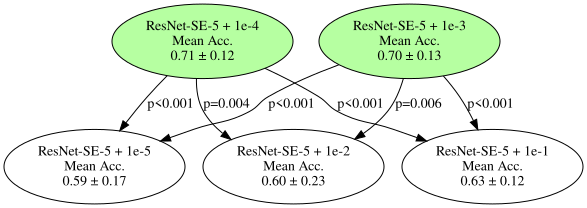

,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score
0,ResNet-SE-5 + 1e-4,0.706948,0.124264,70.7% ± 12.4%,3,0,3
4,ResNet-SE-5 + 1e-3,0.695487,0.127870,69.5% ± 12.8%,3,0,3
1,ResNet-SE-5 + 1e-1,0.631608,0.124987,63.2% ± 12.5%,0,2,-2
3,ResNet-SE-5 + 1e-2,0.602986,0.234499,60.3% ± 23.4%,0,2,-2
2,ResNet-SE-5 + 1e-5,0.592262,0.167586,59.2% ± 16.8%,0,2,-2


,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score
0,ResNet-SE-5 + 1e-4 + SSL,0.706948,0.124264,70.7% ± 12.4%,3,0,3
4,ResNet-SE-5 + 1e-3 + SSL,0.695487,0.127870,69.5% ± 12.8%,3,0,3
1,ResNet-SE-5 + 1e-1 + SSL,0.631608,0.124987,63.2% ± 12.5%,0,2,-2
3,ResNet-SE-5 + 1e-2 + SSL,0.602986,0.234499,60.3% ± 23.4%,0,2,-2
2,ResNet-SE-5 + 1e-5 + SSL,0.592262,0.167586,59.2% ± 16.8%,0,2,-2


In [27]:
import numpy as np
# SSL without ts2vec - will be definitive
dot,df_ssl_rq12 = show_precedence_graph(
    df,
    variants_variables=["backbone","tsk_pretext"],                # Name of the columns to compare (variant)
    filters={
        "select_tsk_pretext": ['1e-3','1e-4','1e-2','1e-1','1e-5'],               # Only use the full dataset
        # "select_ft_strategy": ["Full Finetune",],    # Only use the full finetuning strategy
        "select_backbones": ["ResNet-SE-5"],   # "TS2Vec",  Only use these backbones "TS2Vec",
        # "select_tsk_pretext": [ "S","Diet","TFC","LFR"],  # ,"Supervised" only use these pretext tasks
    },
    show_stdev=True,
    apply_bonferroni= apply_correction_factor,
    filename = "wilcoxon_ssl_rq1"
    
)




summary_df_ssl_rq12 = summarize_backbone_performance(df_ssl_rq12)
display(summary_df_ssl_rq12)
summary_df_ssl_rq12['Backbone'] = summary_df_ssl_rq12['Backbone'] + ' + SSL'

summary_df_ssl_rq12




 -> Querying dataframe (720 rows) with query: 'backbone in @select_backbones'
 -> In-use Variables: {'select_backbones': ['ResNet-SE-5']}
 <- Resulting dataframe has 720 rows.
Bonferroni correction applied: α/10 = 0.005000
Using adjusted p-value


Precedence graph saved to 'results/figures/wilcoxon_ssl_rq1.png'



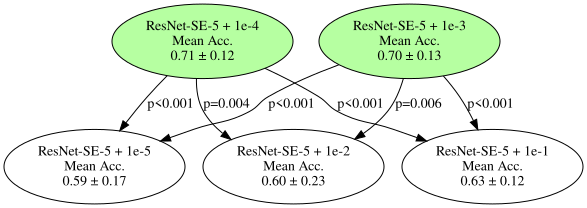

,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score
0,ResNet-SE-5 + 1e-4,0.706948,0.124264,70.7% ± 12.4%,3,0,3
4,ResNet-SE-5 + 1e-3,0.695487,0.127870,69.5% ± 12.8%,3,0,3
1,ResNet-SE-5 + 1e-1,0.631608,0.124987,63.2% ± 12.5%,0,2,-2
3,ResNet-SE-5 + 1e-2,0.602986,0.234499,60.3% ± 23.4%,0,2,-2
2,ResNet-SE-5 + 1e-5,0.592262,0.167586,59.2% ± 16.8%,0,2,-2


In [28]:
import numpy as np

for backbone in df['backbone'].unique():



    # SSL without ts2vec - will be definitive
    dot,df_ssl_rq12 = show_precedence_graph(
        df,
        variants_variables=["backbone","tsk_pretext"],                # Name of the columns to compare (variant)
        filters={
            # "select_tsk_pretext": ['1e-3','1e-4'],               # Only use the full dataset
            # "select_ft_strategy": ["Full Finetune",],    # Only use the full finetuning strategy
            "select_backbones": [backbone],   # "TS2Vec",  Only use these backbones "TS2Vec",
            # "select_tsk_pretext": [ "S","Diet","TFC","LFR"],  # ,"Supervised" only use these pretext tasks
        },
        show_stdev=True,
        apply_bonferroni= apply_correction_factor,
        filename = "wilcoxon_ssl_rq1"
        
    )




summary_df_ssl_rq12 = summarize_backbone_performance(df_ssl_rq12)
display(summary_df_ssl_rq12)
# summary_df_ssl_rq12['Backbone'] = summary_df_ssl_rq12['Backbone'] + ' + SSL'

# summary_df_ssl_rq12




In [29]:
df

,backbone,tsk_pretext,d_pretext,head_pred,ft_strategy,tsk_target,d_target,frac_dtarget,metric_target,metric,lr
1,ResNet-SE-5,1e-5,MS,MLP,Full Finetune,HAR,MS,100.0,accuracy,0.788136,1e-5
2,ResNet-SE-5,1e-3,WISDM,MLP,Full Finetune,HAR,WISDM,10.0,accuracy,0.736943,1e-3
3,ResNet-SE-5,1e-1,MS,MLP,Full Finetune,HAR,MS,1.0,accuracy,0.513183,1e-1
5,ResNet-SE-5,1e-1,UCI,MLP,Full Finetune,HAR,UCI,100.0,accuracy,0.797101,1e-1
6,ResNet-SE-5,1e-2,KH,MLP,Full Finetune,HAR,KH,1000.0,accuracy,0.659722,1e-2
...,...,...,...,...,...,...,...,...,...,...,...
1434,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,100.0,accuracy,0.701613,1e-2
1435,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,5.0,accuracy,0.250000,1e-2
1436,ResNet-SE-5,1e-2,WISDM,MLP,Full Finetune,HAR,WISDM,25.0,accuracy,0.753072,1e-2
1438,ResNet-SE-5,1e-3,RW-Thigh,MLP,Full Finetune,HAR,RW-Thigh,100.0,accuracy,0.694617,1e-3


 -> Querying dataframe (720 rows) with query: 'backbone in @select_backbones'
 -> In-use Variables: {'select_backbones': ['ResNet-SE-5']}
 <- Resulting dataframe has 720 rows.
Bonferroni correction applied: α/10 = 0.005000
Using adjusted p-value


Precedence graph saved to 'results/figures/wilcoxon_ssl_rq1.png'



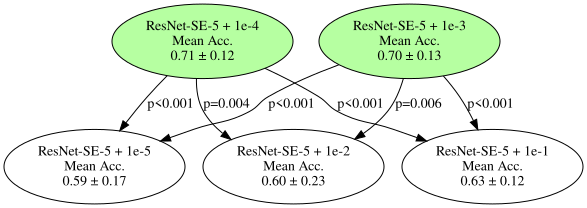

,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score
0,ResNet-SE-5 + 1e-4,0.706948,0.124264,70.7% ± 12.4%,3,0,3
4,ResNet-SE-5 + 1e-3,0.695487,0.127870,69.5% ± 12.8%,3,0,3
1,ResNet-SE-5 + 1e-1,0.631608,0.124987,63.2% ± 12.5%,0,2,-2
3,ResNet-SE-5 + 1e-2,0.602986,0.234499,60.3% ± 23.4%,0,2,-2
2,ResNet-SE-5 + 1e-5,0.592262,0.167586,59.2% ± 16.8%,0,2,-2


,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score
0,ResNet-SE-5 + 1e-4,0.706948,0.124264,70.7% ± 12.4%,3,0,3
1,ResNet-SE-5 + 1e-3,0.695487,0.127870,69.5% ± 12.8%,3,0,3
2,ResNet-SE-5 + 1e-1,0.631608,0.124987,63.2% ± 12.5%,0,2,-2
3,ResNet-SE-5 + 1e-2,0.602986,0.234499,60.3% ± 23.4%,0,2,-2
4,ResNet-SE-5 + 1e-5,0.592262,0.167586,59.2% ± 16.8%,0,2,-2


In [30]:
import numpy as np
dfs_list = []
for backbone in df['backbone'].unique():



    # SSL without ts2vec - will be definitive
    dot,df_ssl_rq12 = show_precedence_graph(
        df,
        variants_variables=["backbone","tsk_pretext"],                # Name of the columns to compare (variant)
        filters={
            # "select_tsk_pretext": ['1e-3','1e-4'],               # Only use the full dataset
            # "select_frac_dtarget": ["200.0","1000.0",],    # Only use the full finetuning strategy
            "select_backbones": [backbone],   # "TS2Vec",  Only use these backbones "TS2Vec",
            # "select_tsk_pretext": [ "S","Diet","TFC","LFR"],  # ,"Supervised" only use these pretext tasks
        },
        show_stdev=True,
        apply_bonferroni= apply_correction_factor,
        filename = "wilcoxon_ssl_rq1"
        
    )




    summary_df_ssl_rq12 = summarize_backbone_performance(df_ssl_rq12)
    display(summary_df_ssl_rq12)
    dfs_list.append(summary_df_ssl_rq12)

summary_df_ssl_rq123 = pd.concat(dfs_list, ignore_index=True)
display(summary_df_ssl_rq123)
# summary_df_ssl_rq12['Backbone'] = summary_df_ssl_rq12['Backbone'] + ' + SSL'

# summary_df_ssl_rq12




In [31]:
summary_df_ssl_rq12 = summary_df_ssl_rq123.copy()

import pandas as pd
from tabulate import tabulate


# df = pd.DataFrame(data)

# Sort by backbone and then by learning rate for better organization
summary_df_ssl_rq12[['Backbone', 'LR']] = summary_df_ssl_rq12['Backbone'].str.split('+', expand=True)
summary_df_ssl_rq12['LR'] = summary_df_ssl_rq12['LR'].str.extract(r'(\d+e-\d+)')[0]
# summary_df_ssl_rq12['LR_num'] = summary_df_ssl_rq12['LR'].str.replace('e-', '').astype(int)
summary_df_ssl_rq12 = summary_df_ssl_rq12.sort_values(['Backbone', 'LR'])
# summary_df_ssl_rq12 = summary_df_ssl_rq12.drop(['LR', 'LR_num'], axis=1)
display(summary_df_ssl_rq12)
# Format for LaTeX table
latex_table = tabulate(summary_df_ssl_rq12, headers='keys', tablefmt='latex_raw', showindex=False)

# Format for markdown (for documentation)
markdown_table = tabulate(summary_df_ssl_rq12, headers='keys', tablefmt='github', showindex=False)

print("LaTeX Table:")
print(latex_table)
print("\nMarkdown Table:")
print(markdown_table)

,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score,LR
2,ResNet-SE-5,0.631608,0.124987,63.2% ± 12.5%,0,2,-2,1e-1
3,ResNet-SE-5,0.602986,0.234499,60.3% ± 23.4%,0,2,-2,1e-2
1,ResNet-SE-5,0.695487,0.127870,69.5% ± 12.8%,3,0,3,1e-3
0,ResNet-SE-5,0.706948,0.124264,70.7% ± 12.4%,3,0,3,1e-4
4,ResNet-SE-5,0.592262,0.167586,59.2% ± 16.8%,0,2,-2,1e-5


LaTeX Table:
\begin{tabular}{lrrlrrrr}
\hline
 Backbone    &     Mean &      Std & Mean ± Std    &   Wins &   Losses &   Net Score &     LR \\
\hline
 ResNet-SE-5 & 0.631608 & 0.124987 & 63.2% ± 12.5% &      0 &        2 &          -2 & 0.1    \\
 ResNet-SE-5 & 0.602986 & 0.234499 & 60.3% ± 23.4% &      0 &        2 &          -2 & 0.01   \\
 ResNet-SE-5 & 0.695487 & 0.12787  & 69.5% ± 12.8% &      3 &        0 &           3 & 0.001  \\
 ResNet-SE-5 & 0.706948 & 0.124264 & 70.7% ± 12.4% &      3 &        0 &           3 & 0.0001 \\
 ResNet-SE-5 & 0.592262 & 0.167586 & 59.2% ± 16.8% &      0 &        2 &          -2 & 1e-05  \\
\hline
\end{tabular}

Markdown Table:
| Backbone    |     Mean |      Std | Mean ± Std    |   Wins |   Losses |   Net Score |     LR |
|-------------|----------|----------|---------------|--------|----------|-------------|--------|
| ResNet-SE-5 | 0.631608 | 0.124987 | 63.2% ± 12.5% |      0 |        2 |          -2 | 0.1    |
| ResNet-SE-5 | 0.602986 | 0.234499 

In [32]:

display(summary_df_ssl_rq12)

,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score,LR
2,ResNet-SE-5,0.631608,0.124987,63.2% ± 12.5%,0,2,-2,1e-1
3,ResNet-SE-5,0.602986,0.234499,60.3% ± 23.4%,0,2,-2,1e-2
1,ResNet-SE-5,0.695487,0.127870,69.5% ± 12.8%,3,0,3,1e-3
0,ResNet-SE-5,0.706948,0.124264,70.7% ± 12.4%,3,0,3,1e-4
4,ResNet-SE-5,0.592262,0.167586,59.2% ± 16.8%,0,2,-2,1e-5
